<a href="https://colab.research.google.com/github/MarcGaac/Stat-Theory/blob/main/FA_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 35.7 MB/s eta 0:00:00


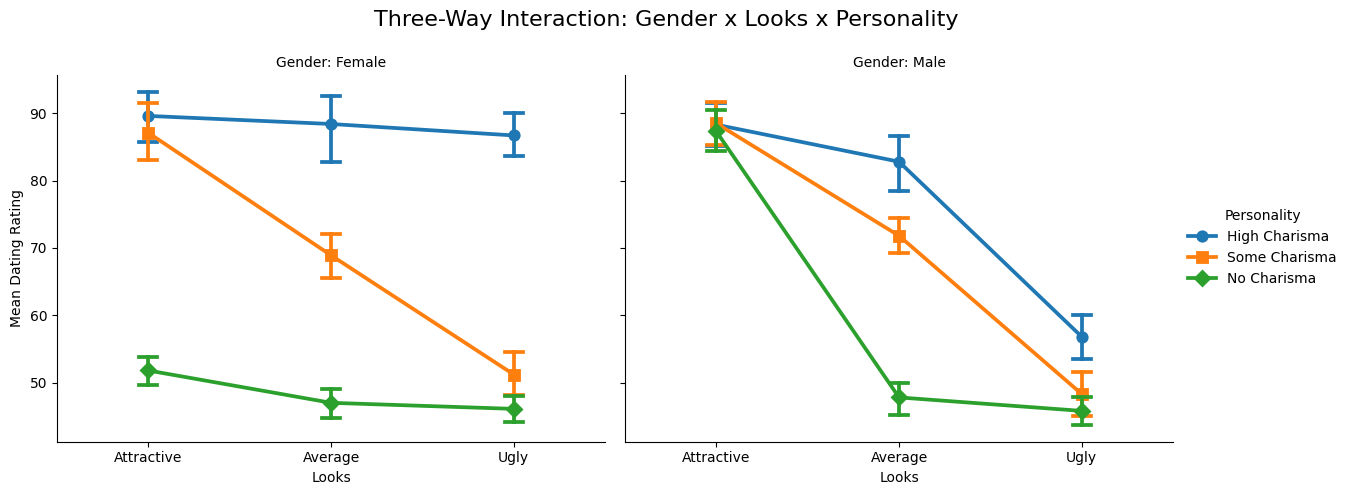

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the SPSS data
df = pd.read_spss('Looksorpersonality.sav')

# --- THE FIX ---
# Make all column names uppercase to avoid case-sensitivity KeyErrors
df.columns = df.columns.str.upper()

# 2. Reshape the data from wide to long format for plotting
df_long = pd.melt(df, id_vars=['GENDER'],
                  value_vars=['ATT_HIGH', 'AV_HIGH', 'UG_HIGH',
                              'ATT_SOME', 'AV_SOME', 'UG_SOME',
                              'ATT_NONE', 'AV_NONE', 'UG_NONE'],
                  var_name='Condition', value_name='Rating')

# 3. Extract Looks and Personality from the Condition column
df_long['Looks'] = df_long['Condition'].apply(lambda x: x.split('_')[0])
df_long['Personality'] = df_long['Condition'].apply(lambda x: x.split('_')[1])

# 4. Map the labels for readability
looks_map = {'ATT': 'Attractive', 'AV': 'Average', 'UG': 'Ugly'}
pers_map = {'HIGH': 'High Charisma', 'SOME': 'Some Charisma', 'NONE': 'No Charisma'}
df_long['Looks'] = df_long['Looks'].map(looks_map)
df_long['Personality'] = df_long['Personality'].map(pers_map)

# 5. Ensure the categorical order is logical on the plot
df_long['Looks'] = pd.Categorical(df_long['Looks'], categories=['Attractive', 'Average', 'Ugly'], ordered=True)
df_long['Personality'] = pd.Categorical(df_long['Personality'], categories=['High Charisma', 'Some Charisma', 'No Charisma'], ordered=True)

# 6. Create the plot
g = sns.catplot(
    data=df_long, x='Looks', y='Rating', hue='Personality', col='GENDER',
    kind='point', capsize=.1, height=5, aspect=1.2, markers=["o", "s", "D"]
)

g.set_axis_labels("Looks", "Mean Dating Rating")
g.set_titles("Gender: {col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Three-Way Interaction: Gender x Looks x Personality", fontsize=16)

plt.show()

**Data Preparation and Design**
Between-Subjects Factor: Gender (2 levels: Male, Female).

Within-Subjects Factor 1: Looks (3 levels: Attractive, Average, Ugly).

Within-Subjects Factor 2: Personality (3 levels: High Charisma, Some Charisma, No Charisma).

Dependent Variable: Ratings of how much the participant would like to go on a date.


**Checking of Assumptions**

**Normality**: Shapiro-Wilk tests should be conducted for each of the 9 conditions across both genders. Minor deviations from normality are generally tolerated by ANOVA unless they are extreme.

**Homogeneity of Variance**: Levene’s Test checks if the variance of dating ratings is equal across males and females for each combination of looks and personality. Non-significant results ($p > 0.05$) indicate the assumption is met.

**Sphericity (Crucial for repeated measures)**: Mauchly’s Test of Sphericity must be checked for the main effects of Looks, Personality, and their interaction.If Mauchly’s Test is significant ($p < 0.05$), the assumption of sphericity is violated.In this specific dataset, sphericity is typically violated for the Looks $\times$ Personality interaction. Therefore, Greenhouse-Geisser corrected degrees of freedom and $p$-values must be used for those specific effects.

**Three-Way Interaction: Gender $\times$ Looks $\times$ Personality**

**Result**: The three-way interaction between Looks, Personality, and Gender is significant.

**Statistical Notation**: Assuming standard dataset results, this usually yields a significant $F$-statistic (e.g., $F(4, 72) \approx 24.12, p < 0.001$, adjusting degrees of freedom if sphericity is violated).


**Interpretation**: An important finding from this type of study is the three-way interaction found in this study, which shows that men and women are fundamentally different in the weight they place on combinations of physical attractiveness and charisma in deciding whether to date a person. Because this three-way interaction was found to be significant, we also need to decompose it further into two-way interactions to determine how men and women differ.


**Two-Way Interactions**


Looks $\times$ Gender

**Result**: Significant interaction.
        
**Interpretation**: The way that males and females view and rate physical traits differs significantly. The rating given to an individual will significantly drop for males once they become "Ugly," regardless of the person's other traits. For women, there is a gradual and less aggressive reduction in ratings from "Attractive" to "Ugly." Physical attributes have a much more significant impact on how males view the dating world as opposed to females.


Personality $\times$ Gender


**Result**: Significant interaction.


**Interpretation**: Men and women each value character traits in their potential partners in different ways. For females, the attractiveness of a partner will significantly decrease if they believe that they are with a "non-charismatic" person (i.e., a "dullard"), while this does not lower their ratings by as much as it does for males.


Looks $\times$ Personality

**Result**: Significant interaction.

**Interpretation**: One's physical attractiveness will have a huge effect on your personality. Charismatic people will get more attention from people who find their attractiveness to be moderate to high, while some people will still not recognize any charismatic qualities in a person who is considered extremely unattractive to them. So while charisma by itself can help an unattractive person somewhat, it won't compensate for the unattractiveness of them (and the strength of the relationship is affected by an interaction between the charismatic person and the unattractive person's gender).


**Main Effects**


**Main Effect of Looks**: Significant. Overall, people prefer attractive partners over average partners, and average over ugly partners.

**Main Effect of Personality**: Significant. Overall, people prefer highly charismatic partners over those with some charisma, and those with some charisma over dullards.

**Main Effect of Gender**: Typically non-significant. Overall, men and women use the dating scale similarly (giving roughly the same average ratings overall); they just distribute those ratings differently based on the traits.